# 04. Adding socioeconomic context

The population-adjusted rankings changed the picture quite a bit. Some states with high raw case counts moved much lower once population was considered, while several smaller jurisdictions moved up substantially.

For the next step, I want to add a small set of socioeconomic measures that may help provide context for those differences:

- median household income
- poverty rate
- unemployment rate

I'm keeping this part intentionally limited. These variables are not being used to explain or predict human trafficking, and any relationship I find will be descriptive rather than causal.

There are many factors that can influence Hotline activity, including awareness, outreach, access to services, reporting behavior, state policy, population characteristics, and the availability of organizations able to identify trafficking situations.

In [1]:
import os
import pandas as pd
import requests

from pathlib import Path
from dotenv import load_dotenv


project_dir = Path.cwd()

if project_dir.name == "notebooks":
    project_dir = project_dir.parent


state_file = (
    project_dir
    / "data"
    / "cleaned"
    / "hotline_population_2024.csv"
)


census_raw_dir = (
    project_dir
    / "data"
    / "raw"
    / "census"
)

census_raw_dir.mkdir(parents=True, exist_ok=True)


state_data = pd.read_csv(
    state_file,
    dtype={"state_fips": "string"}
)


load_dotenv(project_dir / ".env")

census_key = os.getenv("CENSUS_API_KEY")


if not census_key:
    raise ValueError(
        "Census API key not found. Check the .env file in the main project folder."
    )


print(f"State rows loaded: {len(state_data)}")

state_data.head()

State rows loaded: 51


,state,signals_received,pct_total_signals,cases_identified,pct_total_cases,year,state_abbr,state_fips,signals_per_case,raw_case_rank,state_name_census,population_2024,signals_per_100k,cases_per_100k,cases_per_100k_rank,signals_per_100k_rank,rank_change_after_adjustment
0,Alabama,231,0.71,105,0.87,2024,AL,01,2.20,30,Alabama,5086768,4.54,2.06,45,43,-15
1,Alaska,46,0.14,22,0.18,2024,AK,02,2.09,46,Alaska,735706,6.25,2.99,25,24,21
2,Arizona,550,1.70,300,2.50,2024,AZ,04,1.83,10,Arizona,7378838,7.45,4.07,8,19,2
3,Arkansas,170,0.53,80,0.67,2024,AR,05,2.12,35,Arkansas,3049391,5.57,2.62,38,35,-3
4,California,3378,10.46,1734,14.45,2024,CA,06,1.95,1,California,39287377,8.60,4.41,5,8,-4


## Choosing the Census measures

I'm pulling the measures from the 2024 ACS 5-Year Selected Economic Characteristics profile.

The variables used here are:

| Variable | Measure |
| --- | --- |
| `DP03_0062E` | Median household income |
| `DP03_0128PE` | People below the poverty level (%) |
| `DP03_0009PE` | Unemployment rate (%) |

Using the same ACS year and geographic level as the population data keeps the Census portion of the project consistent.

In [2]:
profile_url = (
    "https://api.census.gov/data/2024/acs/acs5/profile"
)


profile_params = {
    "get": (
        "NAME,"
        "DP03_0062E,"
        "DP03_0128PE,"
        "DP03_0009PE"
    ),
    "for": "state:*",
    "key": census_key
}


response = requests.get(
    profile_url,
    params=profile_params,
    timeout=60
)

response.raise_for_status()

profile_json = response.json()


print(f"Census rows returned: {len(profile_json) - 1}")

Census rows returned: 52


## Cleaning the Census response

The Census API returns every value as text, so the economic measures need to be converted back to numeric fields before I can analyze them.

I'm also keeping the Census state name temporarily as a simple check that the FIPS-based join behaves as expected.

In [3]:
economic_context = pd.DataFrame(
    profile_json[1:],
    columns=profile_json[0]
)


economic_context = economic_context.rename(
    columns={
        "NAME": "state_name_census",
        "DP03_0062E": "median_household_income",
        "DP03_0128PE": "poverty_rate",
        "DP03_0009PE": "unemployment_rate",
        "state": "state_fips"
    }
)


economic_context["state_fips"] = (
    economic_context["state_fips"]
    .astype("string")
    .str.zfill(2)
)


numeric_fields = [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate"
]


for column in numeric_fields:
    economic_context[column] = pd.to_numeric(
        economic_context[column],
        errors="coerce"
    )


economic_context.head(10)

,state_name_census,median_household_income,poverty_rate,unemployment_rate,state_fips
0,Alabama,63999,15.6,4.7,01
1,Alaska,92788,10.1,5.9,02
2,Arizona,79964,12.5,5.1,04
3,Arkansas,60773,16.0,4.9,05
4,California,99122,12.0,6.6,06
5,Colorado,95470,9.4,4.6,08
6,Connecticut,95781,10.0,5.6,09
7,Delaware,84954,10.4,5.1,10
8,District of Columbia,109870,15.4,6.3,11
9,Florida,74568,12.6,4.8,12


## Saving the source extract

As with the earlier Census population pull, I'm saving this dataset before joining it to the Hotline data.

That means the project keeps a copy of what came directly from Census as well as the later analysis-ready version.

In [4]:
economic_raw_file = (
    census_raw_dir
    / "acs5_2024_state_economic_context_raw.csv"
)


economic_context.to_csv(
    economic_raw_file,
    index=False
)


print(economic_raw_file)

c:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\raw\census\acs5_2024_state_economic_context_raw.csv


## Joining the economic measures

FIPS code is again the join key.

I expect the original 51 Hotline rows to stay intact and every one of them to receive the three Census measures.

In [5]:
analysis = state_data.merge(
    economic_context[
        [
            "state_fips",
            "state_name_census",
            "median_household_income",
            "poverty_rate",
            "unemployment_rate"
        ]
    ],
    on="state_fips",
    how="left",
    validate="one_to_one"
)


join_check = pd.DataFrame({
    "check": [
        "rows before join",
        "rows after join",
        "missing income values",
        "missing poverty values",
        "missing unemployment values"
    ],
    "result": [
        len(state_data),
        len(analysis),
        analysis["median_household_income"].isna().sum(),
        analysis["poverty_rate"].isna().sum(),
        analysis["unemployment_rate"].isna().sum()
    ]
})


join_check

,check,result
0,rows before join,51
1,rows after join,51
2,missing income values,0
3,missing poverty values,0
4,missing unemployment values,0


## Looking at the highest reporting-rate jurisdictions

Before calculating correlations or doing anything more complicated, I want to see the economic context next to the reporting rates.

This makes it easier to notice whether there is an obvious pattern or whether the high-rate jurisdictions look fairly different from one another.

In [6]:
high_rate_context = (
    analysis[
        [
            "state",
            "cases_identified",
            "cases_per_100k",
            "median_household_income",
            "poverty_rate",
            "unemployment_rate"
        ]
    ]
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)


high_rate_context

,state,cases_identified,cases_per_100k,median_household_income,poverty_rate,unemployment_rate
0,District of Columbia,55,8.07,109870,15.4,6.3
1,Nevada,236,7.41,78260,12.4,7.0
2,Mississippi,195,6.62,56447,18.9,5.8
3,Texas,1360,4.51,78476,13.8,5.3
4,California,1734,4.41,99122,12.0,6.6
5,Missouri,272,4.39,70702,12.6,4.0
6,Kansas,126,4.28,74275,11.3,3.9
7,Arizona,300,4.07,79964,12.5,5.1
8,Montana,43,3.85,72509,11.5,3.6
9,Hawaii,55,3.81,100389,10.0,4.9


## Exploring relationships carefully

For an initial check, I'm comparing the state reporting rate with each socioeconomic measure using Spearman correlation.

I chose Spearman rather than assuming a linear relationship because the state reporting rates are unevenly distributed and the sample is small.

These correlations are exploratory. They do not establish that income, poverty, or unemployment causes changes in human trafficking or Hotline reporting.

In [7]:
context_columns = [
    "cases_per_100k",
    "median_household_income",
    "poverty_rate",
    "unemployment_rate"
]


spearman_matrix = (
    analysis[context_columns]
    .corr(method="spearman")
    .round(3)
)


spearman_matrix

,cases_per_100k,median_household_income,poverty_rate,unemployment_rate
cases_per_100k,1.000,-0.022,0.268,0.268
median_household_income,-0.022,1.000,-0.744,0.147
poverty_rate,0.268,-0.744,1.000,0.379
unemployment_rate,0.268,0.147,0.379,1.000


## Looking at poverty and reporting rates

A scatter plot makes the relationship easier to judge than a correlation coefficient alone.

I'm labeling only a few of the highest reporting-rate jurisdictions so the chart stays readable. The final dashboard will handle state-level exploration more interactively.

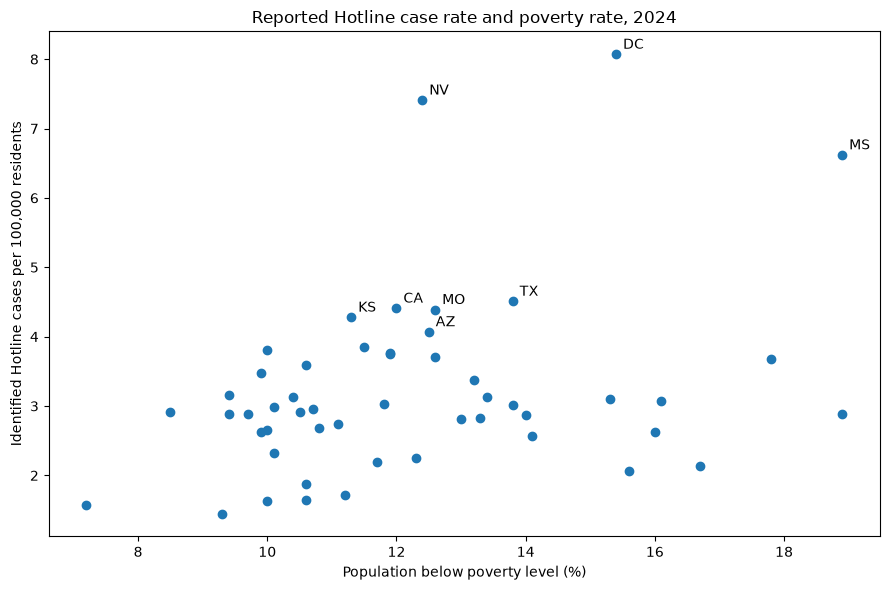

In [8]:
import matplotlib.pyplot as plt


plt.figure(figsize=(9, 6))

plt.scatter(
    analysis["poverty_rate"],
    analysis["cases_per_100k"]
)


label_states = (
    analysis
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .head(8)
)


for _, row in label_states.iterrows():

    plt.annotate(
        row["state_abbr"],
        (
            row["poverty_rate"],
            row["cases_per_100k"]
        ),
        xytext=(5, 4),
        textcoords="offset points"
    )


plt.xlabel("Population below poverty level (%)")
plt.ylabel("Identified Hotline cases per 100,000 residents")

plt.title(
    "Reported Hotline case rate and poverty rate, 2024"
)

plt.tight_layout()
plt.show()

## Income and reporting rates

I'm checking median household income separately because it captures something different from poverty rate.

Again, the purpose here is to identify patterns worth discussing, not to turn economic conditions into a trafficking risk model.

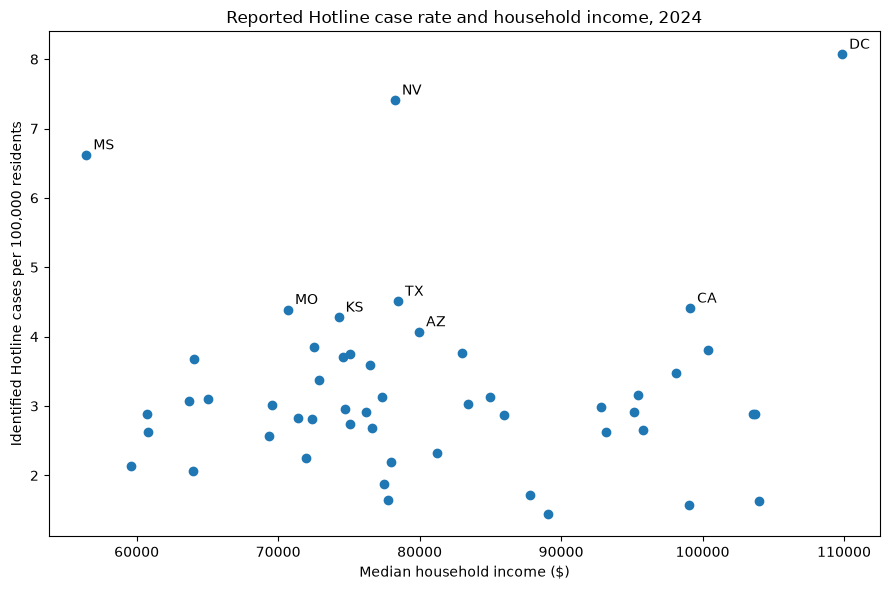

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    analysis["median_household_income"],
    analysis["cases_per_100k"]
)


for _, row in label_states.iterrows():

    plt.annotate(
        row["state_abbr"],
        (
            row["median_household_income"],
            row["cases_per_100k"]
        ),
        xytext=(5, 4),
        textcoords="offset points"
    )


plt.xlabel("Median household income ($)")
plt.ylabel("Identified Hotline cases per 100,000 residents")

plt.title(
    "Reported Hotline case rate and household income, 2024"
)

plt.tight_layout()
plt.show()

## Identifying states for closer review

At this point I don't want to create a single "risk score." That would imply more certainty than these datasets support.

Instead, I'm flagging states that fall into the upper quarter of the population-adjusted Hotline reporting rate. Later I can compare those states with the availability of federally funded victim services and task forces.

That turns the question from "Which states are most at risk?" into a more defensible one:

**Where does relatively high reported need overlap with the service infrastructure captured in the available federal data?**

In [10]:
rate_threshold = analysis["cases_per_100k"].quantile(0.75)


analysis["higher_reporting_rate"] = (
    analysis["cases_per_100k"]
    >= rate_threshold
)


higher_rate_states = (
    analysis[
        analysis["higher_reporting_rate"]
    ][
        [
            "state",
            "cases_per_100k",
            "poverty_rate",
            "unemployment_rate",
            "median_household_income"
        ]
    ]
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    f"Upper-quartile reporting threshold: "
    f"{rate_threshold:.2f} cases per 100k"
)

higher_rate_states

Upper-quartile reporting threshold: 3.70 cases per 100k


,state,cases_per_100k,poverty_rate,unemployment_rate,median_household_income
0,District of Columbia,8.07,15.4,6.3,109870
1,Nevada,7.41,12.4,7.0,78260
2,Mississippi,6.62,18.9,5.8,56447
3,Texas,4.51,13.8,5.3,78476
4,California,4.41,12.0,6.6,99122
5,Missouri,4.39,12.6,4.0,70702
6,Kansas,4.28,11.3,3.9,74275
7,Arizona,4.07,12.5,5.1,79964
8,Montana,3.85,11.5,3.6,72509
9,Hawaii,3.81,10.0,4.9,100389


## Saving the expanded state dataset

The state table now includes:

- Hotline signal and case counts
- population-adjusted reporting rates
- raw and adjusted rankings
- median household income
- poverty rate
- unemployment rate

The next stage will add information about federally funded anti-trafficking victim services and task forces.

In [11]:
context_file = (
    project_dir
    / "data"
    / "cleaned"
    / "hotline_state_context_2024.csv"
)


analysis.to_csv(
    context_file,
    index=False
)


print(context_file)

c:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\cleaned\hotline_state_context_2024.csv
